In [4]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import seaborn as sns

from datetime import datetime as dt
from datetime import timedelta
import os

import matplotlib.cm as cm
from brokenaxes import brokenaxes

pd.options.mode.chained_assignment = None 
import matplotlib.ticker as ticker

In [6]:
folder_name = "./Figures/CompareBaselines/"

In [7]:
def read(dataset, compare, filename):
    df = pd.read_csv(filename, header = 0)
    return df#create_query_bin(df)


In [8]:
def get_used_attrs(df):
    attrs = []
    for i in df['queryText'].unique():
        splitted = i.split(' ')
        for s in splitted:
            if "=" in s:
                continue
            if s.isnumeric():
                continue
            if '-' in s:
                continue
            if 'and' in s:
                continue
            if s not in attrs:
                attrs.append(s)
    print(attrs)
    return len(attrs)
    print("{} Distinct attributes used in predicates".format(len(attrs)))
    

In [9]:
def preprocess(df, p, keepAll=False):
    def replace_comma_with_dot_and_convert_to_float(column_name):
        if column_name in df.columns[df.dtypes == 'object']:
            df[column_name] = df[column_name].str.replace(',', '.').astype({column_name: float})

    replace_comma_with_dot_and_convert_to_float('relError')
    replace_comma_with_dot_and_convert_to_float('epsError')

    df['Sketch Memory (MB)'] = df['memUsageSynopsis'] / 1e6
    df['Dataset Memory (MB)'] = df['memUsageDataset'] / 1e6
    df['Speedup'] = df['exactTime'] / df['estTime']
    df['Time Est (ms)'] = df['estTime']
    df['Avg Update Time (ms)'] = df['Avg Update Time']
    df['Time exact (ms)'] = df['exactTime']
    df['relMemFootprint'] = df['Sketch Memory (MB)'] / df['Dataset Memory (MB)']
    df['thrm33case2'] = np.where(df['setting'] != 'OmniSketch', True, df['thrm33case2'])
    df['RAM'] = df['RAM'] / (8e6)

    if not keepAll:
        df = df[df['numPredicates'] == p]

    df['altAbsError'] = np.where(df['setting'] == 'OmniSketch',
                                 abs(df['case2Estimate'] - df['exactAnswer']),
                                 df['absError'])
    df['altEpsError'] = df['altAbsError'] / df['streamSize']  # Alternative epsError.
    df['altNullAbsError'] = np.where(df['thrm33case2'] == False,
                                     df['exactAnswer'],
                                     abs(df['estimate'] - df['exactAnswer']))
    df['altNullEpsError'] = df['altNullAbsError'] / df['streamSize']
    df['d'], df['w'], df['B'], df['b'] = 0, 0, 0, 0

    for k, v in df.iterrows():
        pars = [int(i) for i in list(v['parameters'].replace("[", "").replace("]", "").split(", "))]
        if v['setting'] == "OmniSketch":
            df.loc[k, 'd'], df.loc[k, 'w'], df.loc[k, 'B'], df.loc[k, 'b'] = pars

    df['histSetting'] = df['setting'] + df['RAM'].astype(str)
    setting_map = {
        'Sketch0Cap': r'$\mathbb{S}0_{\cap}$',
        'Sketch0Min': r'$\mathbb{S}0_{\min}$',
        'OmniSketch10.0': r'$\mathbb{S}1 (10 MB)$',
        'OmniSketch50.0': r'$\mathbb{S}1 (50 MB)$',
        'OmniSketch100.0': r'$\mathbb{S}1 (100 MB)$',
        'OmniSketch200.0': r'$\mathbb{S}1 (200 MB)$',
        'Hydra10.0': 'Hydra (10 MB)',
        'Hydra50.0': 'Hydra (50 MB)',
        'Hydra100.0': 'Hydra (100 MB)',
        'Hydra200.0': 'Hydra (200 MB)'
    }
    df['histSetting'] = df['histSetting'].replace(setting_map)

    for numAttrs in df['numAttributes'].unique():
        dfa = df[df['numAttributes'] == numAttrs]
        usedAttrs = get_used_attrs(dfa)
        df.loc[df['numAttributes'] == numAttrs, 'numAttributesInWorkload'] = usedAttrs

    return df

In [10]:
def set_size(size):
    font = {'family' : 'serif',
        'weight' : 'normal',
        'size'   : size}
    matplotlib.rc('font', **font)
set_size(12)

In [7]:
dataset = "SNMP"
#filename = "outputODC/results_Compare Baselines_CAIDA_2023-07-28.csv"
# Used in paper: 2023-08-22
#filename = "outputODC/compare baselines/results_Compare Baselines_SNMP_2023-08-22_Rep1.csv"
#filename = "outputODC/CBWithDiffHashKeys/results_Compare Baselines_SNMP_2023-08-27_Rep1.csv"

def r(add):
    
    filename = "output/results_Compare Baselines_SNMP_2023-09-22_Rep1{}.csv".format(add)
    df = read(dataset, True, filename)
    p = 2
    df = preprocess(df, p, True)
    return df
df_all = r('')
df_loo = r('_Loo')
df_lto = r('_LTO')



['ifOutOctets', 'ifOutErrors']
['ifInDiscards', 'ifOutOctets', 'ifOutErrors']
['ifInDiscards', 'ifOutOctets', 'AP', 'ifOutErrors']
['ifInDiscards', 'ifOutOctets', 'ifDescr', 'AP', 'ifOutErrors']
['ifInDiscards', 'ifOutOctets', 'ifDescr', 'AP', 'ifOutErrors', 'ifOutUcastPkts']
['ifInDiscards', 'ifOutOctets', 'ifDescr', 'ifInUcastPkts', 'AP', 'ifOutUcastPkts', 'ifOutErrors']
['ifInDiscards', 'ifOutOctets', 'ifDescr', 'ifInUcastPkts', 'AP', 'ifOutUcastPkts', 'ifOutErrors', 'ifInOctets']
['ifInDiscards', 'ifOutOctets', 'ifDescr', 'ifInErrors', 'ifInUcastPkts', 'AP', 'ifOutUcastPkts', 'ifOutErrors', 'ifInOctets']
['ifOutOctets', 'awcFtClientSTASelf', 'ifInErrors', 'ifInDiscards', 'ifDescr', 'ifInUcastPkts', 'AP', 'ifOutUcastPkts', 'ifOutErrors', 'ifInOctets']
['ifOutOctets', 'awcFtClientSTASelf', 'ifInErrors', 'ifOutDiscards', 'ifInDiscards', 'ifDescr', 'AP', 'ifInUcastPkts', 'ifOutUcastPkts', 'ifOutErrors', 'ifInOctets']
['ifOutOctets', 'ifOutErrors']
['ifInDiscards', 'ifOutOctets', 'ifOut

In [8]:

histSetting_style_dict = {
    '$\\mathbb{S}0_{\\min}$': {'marker': 'o', 'color': 'blue', 'linestyle': '-'},
    '$\\mathbb{S}0_{\\cap}$': {'marker': 's', 'color': 'green', 'linestyle': '--'},
    '$\\mathbb{S}1 (10 MB)$': {'marker': '^', 'color': 'orange', 'linestyle': '-'},
    '$\\mathbb{S}1 (50 MB)$': {'marker': 'D', 'color': 'red', 'linestyle': '-'},
    '$\\mathbb{S}1 (100 MB)$': {'marker': 'v', 'color': 'purple', 'linestyle': '-'},
    '$\\mathbb{S}1 (200 MB)$': {'marker': '*', 'color': 'black', 'linestyle': '-'},
    'Hydra (10 MB)': {'marker': 'X', 'color': 'lime', 'linestyle': '-.'},
    'Hydra (50 MB)': {'marker': '+', 'color': 'blue', 'linestyle': '-.'},
    'Hydra (100 MB)': {'marker': 'P', 'color': 'deeppink', 'linestyle': '-.'},
    'Hydra (200 MB)': {'marker': 'H', 'color': 'grey', 'linestyle': '-.'},
    'OmniSketch_2': {'marker': 'D', 'color': 'brown', 'linestyle': ':'},
    'OmniSketch_3': {'marker': 's', 'color': 'darkblue', 'linestyle': '-.'},
    'Hydra_2': {'marker': 'o', 'color': 'teal', 'linestyle': '-'},
    'Hydra_3': {'marker': 'v', 'color': 'indigo', 'linestyle': '--'},
    'OmniSketch_2_50': {'marker': 'X', 'color': 'gold', 'linestyle': '-.'},
    'OmniSketch_3_50': {'marker': 'P', 'color': 'pink', 'linestyle': ':'},
    'Hydra_2_50': {'marker': 's', 'color': 'darkgreen', 'linestyle': '-'},
    'Hydra_3_50': {'marker': '*', 'color': 'coral', 'linestyle': '--'},
    'OmniSketch_2_100': {'marker': 'D', 'color': 'lavender', 'linestyle': '-.'},
    'OmniSketch_3_100': {'marker': 'H', 'color': 'chocolate', 'linestyle': ':'},
    'Hydra_2_100': {'marker': '^', 'color': 'gold', 'linestyle': '-'},
    'Hydra_3_100': {'marker': 'o', 'color': 'darkred', 'linestyle': '--'},
    'Hydra_4': {'marker': 'X', 'color': 'goldenrod', 'linestyle': '-.'},
    'OmniSketch_4': {'marker': 'D', 'color': 'deeppink', 'linestyle': ':'},
    'Hydra_4_50': {'marker': '+', 'color': 'lightseagreen', 'linestyle': '-'},
    'OmniSketch_4_50': {'marker': 'H', 'color': 'crimson', 'linestyle': '--'},
    'Hydra_4_100': {'marker': 'P', 'color': 'goldenrod', 'linestyle': '-.'},
    'Hydra_4_200': {'marker': 'P', 'color': 'goldenrod', 'linestyle': '-.'},
    'OmniSketch_4_100': {'marker': 'v', 'color': 'hotpink', 'linestyle': ':'},
    'Hydra_5': {'marker': 'X', 'color': 'darkcyan', 'linestyle': '-'},
    'OmniSketch_5': {'marker': 'D', 'color': 'deeppink', 'linestyle': '--'},
    'Hydra_5_50': {'marker': '+', 'color': 'lightseagreen', 'linestyle': '-.'},
    'OmniSketch_5_50': {'marker': 'H', 'color': 'crimson', 'linestyle': ':'},
    'Hydra_5_100': {'marker': 'P', 'color': 'goldenrod', 'linestyle': '-'},
    'OmniSketch_5_100': {'marker': 'v', 'color': 'hotpink', 'linestyle': '--'},
    'Hydra_6': {'marker': 'X', 'color': 'black', 'linestyle': '-.'},
    'OmniSketch_6': {'marker': 'D', 'color': 'gray', 'linestyle': ':'},
    'Hydra_6_50': {'marker': '+', 'color': 'darkblue', 'linestyle': '-'},
    'OmniSketch_6_50': {'marker': 'H', 'color': 'darkgreen', 'linestyle': '--'},
    'Hydra_6_100': {'marker': 'P', 'color': 'darkred', 'linestyle': '-.'},
    'OmniSketch_6_100': {'marker': 'v', 'color': 'darkcyan', 'linestyle': ':'},
    'Hydra_7': {'marker': '^', 'color': 'lime', 'linestyle': '-'},
    'OmniSketch_7': {'marker': 'D', 'color': 'indigo', 'linestyle': '--'},
    'Hydra_7_50': {'marker': 'X', 'color': 'crimson', 'linestyle': '-.'},
    'OmniSketch_7_50': {'marker': 'H', 'color': 'gold', 'linestyle': ':'},
    'Hydra_7_100': {'marker': 'P', 'color': 'deeppink', 'linestyle': '-'},
    'OmniSketch_7_100': {'marker': 'v', 'color': 'darkgreen', 'linestyle': '--'},
    'Hydra_8': {'marker': 'o', 'color': 'brown', 'linestyle': '-.'},
    'OmniSketch_8': {'marker': 's', 'color': 'darkblue', 'linestyle': ':'},
    'Hydra_8_50': {'marker': '+', 'color': 'darkgreen', 'linestyle': '-'},
    'OmniSketch_8_50': {'marker': 'H', 'color': 'coral', 'linestyle': '--'},
    'Hydra_8_100': {'marker': 'P', 'color': 'lavender', 'linestyle': '-.'},
    'OmniSketch_8_100': {'marker': 'v', 'color': 'chocolate', 'linestyle': ':'},
    'Hydra_9': {'marker': '^', 'color': 'gold', 'linestyle': '-'},
    'OmniSketch_9': {'marker': 'D', 'color': 'crimson', 'linestyle': '--'},
    'Hydra_9_50': {'marker': 'X', 'color': 'darkblue', 'linestyle': '-.'},
    'OmniSketch_9_50': {'marker': 'H', 'color': 'darkgreen', 'linestyle': ':'},
    'Hydra_9_100': {'marker': 'P', 'color': 'darkred', 'linestyle': '-'},
    'OmniSketch_9_100': {'marker': 'v', 'color': 'darkcyan', 'linestyle': '--'},
    'Hydra_10': {'marker': 'o', 'color': 'black', 'linestyle': '-.'},
    'OmniSketch_10': {'marker': 's', 'color': 'gray', 'linestyle': ':'},
    'Hydra_10_50': {'marker': '+', 'color': 'lightseagreen', 'linestyle': '-'},
    'OmniSketch_10_50': {'marker': 'H', 'color': 'darkgreen', 'linestyle': '--'},
    'Hydra_10_100': {'marker': 'P', 'color': 'darkred', 'linestyle': '-.'},
    'OmniSketch_10_100': {'marker': 'v', 'color': 'deeppink', 'linestyle': ':'}
}
# Define a dictionary to map 'aggr' to linestyle
aggr_dict = {
    'altEpsError': '-',
    'IT': '--',
    'execTime': ':'
}

# Get the unique MB values from the 'histSetting' column
unique_MB_values = (df['RAM']).unique()
print(unique_MB_values)
# Calculate the normalized values for the color map
#normalized_MB = [(MB - min(unique_MB_values)) / (max(unique_MB_values) - min(unique_MB_values)) for MB in unique_MB_values]



# Function to get color based on 'histSetting'
def get_color(histSetting, psetting = False):
    if psetting:
        if 'Hydra' in histSetting:
        # Create a color map based on the MB values
            color_map = cm.get_cmap('plasma')
        elif 'Omni' in histSetting:
            color_map = cm.get_cmap('cividis')
        else:
            print("No colormap defined for setting {}".format(histSetting))
        p = int(histSetting.split('_')[1].replace('_', ''))
        normalized_p_value = (p - 2) / (1)
        print(histSetting)
        return histSetting_style_dict.get(histSetting)['color']#color_map(normalized_p_value)
    
    if '{S}0' in histSetting:
        return histSetting_style_dict.get(histSetting)['color']
    if 'Hydra' in histSetting:
        # Create a color map based on the MB values
        color_map = cm.get_cmap('tab20')
    elif '{S}1' in histSetting:
        color_map = cm.get_cmap('tab20')
    else:
        print("No colormap defined for setting {}".format(histSetting))
    MB = int(histSetting.split(' ')[1].replace('(', ''))
    normalized_MB_value = (MB - min(unique_MB_values)) / (max(unique_MB_values) - min(unique_MB_values))
    return histSetting_style_dict.get(histSetting)['color']#color_map(normalized_MB_value)


NameError: name 'df' is not defined

# Ingestion time

### - Y axis ingestion time
### - X axis searchable attributes
### - 3 different RAM values

### - Also show number of subpopulations that corresponds to number of attributes.

In [ ]:
def extract_x_from_setting(setting):
    # Extract the numeric value of "x" from the setting
    if 'Hydra' in setting:
        return int(setting.split(' (')[1].split(' MB)')[0])
    else:
        return int(setting.split(' (')[1].split(' MB)')[0])
def plot_ingest(df):
    grouped_df = df.groupby(['numAttributesInWorkload', 'histSetting', 'RAM', 'streamSize'])['Avg Update Time'].mean().reset_index()

    # Create a plot with broken y-axis
    fig, (ax2, ax1) = plt.subplots(2, 1, figsize=(8, 6), sharex=True)

    # Initialize a dictionary to keep track of plotted labels
    plotted_labels = {}
    plotted_labels_hydra = {}
    import matplotlib
    set_size(11)
    for i, ((setting, RAM), data) in enumerate(grouped_df.groupby(['histSetting', 'RAM'])):
        
        style = histSetting_style_dict.get(setting, {'marker': 'o'})
        filtered_data = data[['numAttributesInWorkload', 'Avg Update Time', 'streamSize']]

        if 'Hyd' in setting:
            # Plot the data on the upper y-axis (500-3000 scale)
            line2, = ax2.plot(filtered_data['numAttributesInWorkload'],
                              filtered_data['Avg Update Time']*filtered_data['streamSize']/1000,#*filtered_data['streamSize']/1000,
                              label=f'{setting}',
                              color=get_color(setting),
                          marker=style['marker'],
                             linestyle = style['linestyle'])
            

        # Plot the data on the lower y-axis (0-100 scale)
        line1, = ax1.plot(filtered_data['numAttributesInWorkload'],
                          filtered_data['Avg Update Time']*filtered_data['streamSize']/1000,#*filtered_data['streamSize']/1000,
                          label=f'{setting}',
                          color=get_color(setting),
                          marker=style['marker'],
                             linestyle = style['linestyle'])
        if 'Hyd'in setting:
            
            plotted_labels_hydra[setting] = line1
        else:
            plotted_labels[setting] = line1
    font = {'family' : 'serif',
            'weight' : 'normal',
            'size'   :300}

    matplotlib.rc('font', **font)
    # Set labels and title for the upper y-axis (500-3000 scale)
    ax2.set_ylabel('Ingestion Time (seconds)', fontsize=15)
    ax2.set_ylim(100, 15000)
    ax2.set_yticks([100, 2500,5000, 7500, 10000, 12500, 15000],  fontsize=15)

    # Set labels and title for the lower y-axis (0-100 scale)
    ax1.set_ylabel('Ingestion Time (seconds)',  fontsize=15)
    ax1.set_ylim(0, 100)
    ax1.set_yticks(range(0, 1, 20) , fontsize=15)

    # Add a break line between the two y-axis scales
    ax1.set_yscale('function', functions=(lambda x: x*10, lambda x: x/10))

    # Set x-ticks
    x_ticks = filtered_data['numAttributesInWorkload'].tolist()
    ax2.set_xticks(x_ticks,  fontsize=15)

    # Set the x-axis limits for both ax1 and ax2
    ax1.set_xlim(2, 11)
    ax2.set_xlim(2, 11)

    plt.xticks(range(2, 12))
    # Create a single combined legend outside the plots
    
    # Display the plot
    plt.xlabel('Number of Stored Attributes', fontsize=15)
    lines = []
    labels = []

    for setting in sorted(plotted_labels, key=extract_x_from_setting):
        line = plotted_labels[setting]
        lines.append(line)
        labels.append(line.get_label())

    for setting in sorted(plotted_labels_hydra, key=extract_x_from_setting):
        line = plotted_labels_hydra[setting]
        lines.append(line)
        labels.append(line.get_label())
        
    font = {'family' : 'serif',
            'weight' : 'normal',
            'size'   : 12}

    matplotlib.rc('font', **font)
    fig.legend(lines, labels, fontsize='large', bbox_to_anchor=(0.45, 0.95), loc='upper center', ncol=2)

    plt.tight_layout()
    plt.show()

    fig.savefig(folder_name + "{}_{}.pdf".format("Compare_IT", dataset), format="pdf", bbox_inches="tight")

plot_ingest(df)

# Query Execution Time
### y-axis: query execution time
### x-axis: Memory of sketch
### Show for 3 different values of p


In [ ]:
all_ids = []

for i in df['numPredicates'].unique():
    df1 = df[df['numPredicates'] == i]
    df1 = df1[df1['numAttributesInWorkload'] == i]
    ids = df1['queryID'].unique()
    idslen = len(ids)
    previdslen = len(all_ids)
    for j in ids:
        all_ids.append(j)
    print("all ids is now {} and should be {}".format(len(all_ids), idslen + previdslen))
df_cons = df[df['queryID'].isin(all_ids)]

In [ ]:
df1 = df[df['numAttributesInWorkload'] == 11]

grouped_df = df1.groupby(['histSetting', 'numPredicates'])['estTime'].mean().reset_index()

# Rename columns
grouped_df = grouped_df.rename(columns={
    'histSetting': 'setting',
    'numPredicates': 'p',
    'estTime': 'Query Execution Time'
})

# Pivot the DataFrame to get the desired format
pivot_df = grouped_df.pivot(index='setting', columns='p', values='Query Execution Time')

# Sort the columns by p
pivot_df = pivot_df.reindex(sorted(pivot_df.columns), axis=1)

# Generate the LaTeX table
latex_table = pivot_df.to_latex(float_format="%.2f", na_rep='-', multicolumn_format='c', multicolumn=True, column_format='l|ll|', index_names=False)

# Print the LaTeX table
print(latex_table)

# Accuracy
### y-axis abs error / N
### X-axis searchable attrs p
### For different vals of RAM

In [ ]:
df_loo

In [ ]:
def cons(df):
    all_ids = []

    for i in df['numPredicates'].unique():
        if i < 5:
            df1 = df[df['numPredicates'] == i]
            df1 = df1[df1['numAttributesInWorkload'] == i]
            ids = df1['queryID'].unique()
            idslen = len(ids)
            previdslen = len(all_ids)
            for j in ids:
                all_ids.append(j)
            print("all ids is now {} and should be {}".format(len(all_ids), idslen + previdslen))
    df_cons = df[df['queryID'].isin(all_ids)]
    return df_cons
all_df = cons(df_all)
loo = cons(df_loo)
lto = cons(df_lto)

In [ ]:
def plot_acc(df):
    df = df[df['RAM'] == 100]
    
    grouped_df = df.groupby(['numAttributesInWorkload', 'RAM',
                             'numPredicates', 'setting'])['altEpsError'].mean().reset_index()

    # Set up the plot
    fig, ax = plt.subplots()
    font = {'family' : 'serif',
            'weight' : 'normal',
            'size'   : 11}

    matplotlib.rc('font', **font)
    for i, ((num_predicates, setting, ram), data) in enumerate(grouped_df.groupby(['numPredicates', 'setting', 'RAM'])):
        p_ram_setting = setting + "_"+ str(num_predicates)# + "_"+ str(ram)
        print(p_ram_setting)
        style = histSetting_style_dict.get(p_ram_setting, {'marker': 'o'})
        filtered_data = data[['numAttributesInWorkload', 'altEpsError']]

        # Plot the data
        ax.plot(filtered_data['numAttributesInWorkload'],
                filtered_data['altEpsError'],linestyle='-', linewidth=1,
                label="{} ({} MB), p = {}".format(setting.replace("OmniSketch", r'$\mathbb{S}1$'),
                                                  str(ram).replace(".0",""),
                                                  num_predicates),
                color = style['color'], marker = style['marker'])
    ax.legend(loc='upper left', fontsize='large')
    # Set labels and title
    font = {'family' : 'serif',
            'weight' : 'normal',
            'size'   : 12}

    matplotlib.rc('font', **font)
    ax.set_xlabel('Number of Stored Attributes')
    ax.set_ylabel('Observed Error ({})'.format(r'$\times 10^{-5}$'))
    title = 'Observed Error vs. num Attributes'
    x_ticks = filtered_data['numAttributesInWorkload'].tolist()
    ax.set_xticks(x_ticks)
    ax.set_ylim(0, 2e-5)
    ax.set_xlim(2, 11)

    plt.xticks(range(2, 12))
    ax.yaxis.set_major_locator(ticker.MultipleLocator(base=1e-5))  # Set ticks at every 1e6
    ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{int(x/(1e-5))}'))
    
    # Display the plot
    plt.show()
    
    fig.savefig(folder_name + "{}_{}.pdf".format(title.replace(" ", "_"), dataset), format="pdf", bbox_inches="tight" )
    

In [ ]:
plot_acc(all_df)

OmniSketch_2
OmniSketch_3
OmniSketch_4


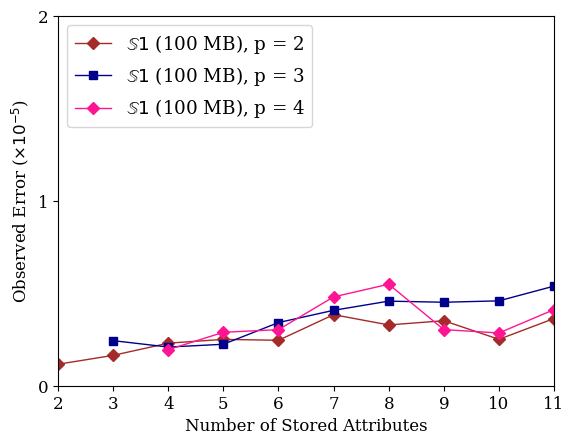

In [73]:
plot_acc(loo)

OmniSketch_2
OmniSketch_3
OmniSketch_4


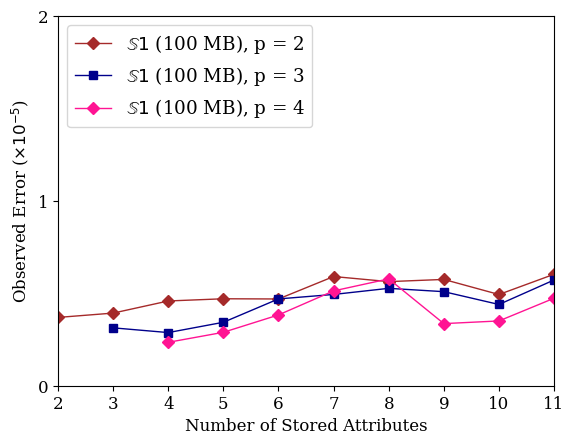

In [74]:
plot_acc(lto)